In [1]:
import torch
device = torch.device('cuda:0')
import pandas as pd
from go_ml.train_utils import get_enzyme_df, enzyme_iterator
import transformers
tokenizer = transformers.AutoTokenizer.from_pretrained('facebook/esm2_t6_8M_UR50D')
enzyme_df = get_enzyme_df()
enzyme_l = list(enzyme_iterator(enzyme_df, tokenizer))

In [2]:
test_prot = enzyme_l[8]

1. Get logits for P(Seq)
2. Generate ~4000 samples for protein, eval function likelihood on all
3. Train cond_logit and log_prior to match function likelihood

### Prior probability of sequence from BERT model

In [3]:
# from transformers import AutoModelForMaskedLM
# from transformers import AutoTokenizer, AutoConfig
# import torch

# tokenizer = AutoTokenizer.from_pretrained('facebook/esm2_t6_8M_UR50D')
# config = AutoConfig.from_pretrained('facebook/esm2_t6_8M_UR50D')
# model = AutoModelForMaskedLM.from_pretrained('facebook/esm2_t6_8M_UR50D').to(device)
# model.eval()

# def mask_seq(seq_ind, attention_mask, mask_token, residue_coverage=6, mut_per=0.15):
#     device = seq_ind.device
#     seq_len = attention_mask.sum()-1
#     mut_count = torch.floor(seq_len*mut_per).int().item()
#     total_muts = (torch.floor(seq_len*residue_coverage/mut_count)*mut_count).int().item()
    
#     mut_inds = (torch.randperm(total_muts).reshape(-1, mut_count).to(device) % seq_len) + 1
#     batch_inds = torch.tile(torch.arange(0, mut_inds.shape[0]).reshape((-1, 1)), (1, mut_count))
#     mut_inds, batch_inds = mut_inds.to(device), batch_inds.to(device)

#     batch = torch.tile(seq_ind, (mut_inds.shape[0], 1))
#     batch[batch_inds, mut_inds] = mask_token
#     return batch, batch_inds, mut_inds

# with torch.no_grad():
#     seq_ind, mask =  torch.tensor(test_prot['seq_ind']).to(device), torch.BoolTensor(test_prot['mask']).to(device)
#     residue_coverage = 6
#     seq_batch, batch_inds, mut_inds = mask_seq(seq_ind[:, :], mask[:, :], tokenizer.mask_token_id, residue_coverage=residue_coverage)
#     coverage_counts = torch.zeros(seq_ind.shape[1]).to(device)
#     for r in mut_inds:
#         coverage_counts[r] += 1
#     bert_pred = model(seq_batch, torch.tile(mask, (seq_batch.shape[0], 1)))
#     mut_distr = torch.softmax(bert_pred.logits, dim=2)
#     mut_distr.shape
#     N, L, T = bert_pred.logits.shape
#     bert_distr = torch.zeros(L, T, device=device)
#     for bi, ti in zip(batch_inds.flatten(), mut_inds.flatten()):
#         bert_distr[ti, :] += mut_distr[bi, ti, :]
#     bert_distr /= residue_coverage

In [4]:
# import pickle
# with open('notebook_cache/test_bert_distr.pkl', 'wb') as f:
#     pickle.dump(bert_distr, f)

### Eval mutations

In [5]:
import pickle
with open('notebook_cache/test_bert_distr.pkl', 'rb') as f:
    bert_distr = pickle.load(f)

In [6]:
import numpy as np
def mutate_ind(seq, lambda_=15):
    amino_acids = "ACDEFGHIKLMNPQRSTVWY"
    mut_seq = np.array(list(seq))
    num_changes = np.random.poisson(lambda_)
    indices_to_change = np.random.choice(len(seq), num_changes, replace=False)
    mut_seq[indices_to_change] = np.random.choice(list(amino_acids), num_changes)
    mut_seq = ''.join(mut_seq)
    return mut_seq, num_changes

mut_seq = [mutate_ind(test_prot['seq'], lambda_=45) for _ in range(5000)]

from go_ml.data_utils import ProtDataset, get_seq_collator
from torch.utils.data import DataLoader

mut_ds = ProtDataset(['csatest']*len(mut_seq), [x[0] for x in mut_seq])
collate_seqs = get_seq_collator(tokenizer, max_length=1024, add_special_tokens=True)
mut_dl = DataLoader(mut_ds, shuffle=False, batch_size=60, collate_fn=collate_seqs)

In [7]:
# from go_ml.models.bert_finetune import BERTFinetune
# checkpoint_dir = "/home/andrew/GO_interp/checkpoints"
# # with open(f"{checkpoint_dir}/esm_finetune_hparams.pkl", "rb") as f:
# #     hparams = pickle.load(f)
# model = BERTFinetune.load_from_checkpoint(f"{checkpoint_dir}/esm_finetune-v1.ckpt", map_location=device)
# model.eval()

# import tqdm.notebook
# TQDM_BAR_FORMAT = '{l_bar}{bar}| {n_fmt}/{total_fmt} [elapsed: {elapsed} remaining: {remaining}]'
# with tqdm.notebook.tqdm(total=len(mut_dl), bar_format=TQDM_BAR_FORMAT) as pbar:
#     with torch.no_grad():
#         logit_l = []
#         for batch in mut_dl:
#             seq_ind, mask = batch['seq_ind'].to(device), batch['mask'].to(device)
#             logit_preds = model.forward(seq_ind, mask)
#             logit_l.append(logit_preds)
#             pbar.update(len(logit_l))
#         logit_preds = torch.cat(logit_l)

In [8]:
# import pickle
# with open('notebook_cache/test_mut_eval_45_poisson.pkl', 'wb') as f:
#     pickle.dump((mut_seq, logit_preds.cpu()), f)
    
with open('notebook_cache/test_mut_eval_45_poisson.pkl', 'rb') as f:
    mut_seq, logit_preds = pickle.load(f)
    
from go_ml.data_utils import ProtDataset, get_seq_collator
from torch.utils.data import DataLoader

mut_ds = ProtDataset(['csatest']*len(mut_seq), [x[0] for x in mut_seq])
collate_seqs = get_seq_collator(tokenizer, max_length=1024, add_special_tokens=True)
mut_dl = DataLoader(mut_ds, shuffle=False, batch_size=60, collate_fn=collate_seqs)

In [9]:
print(bert_distr.shape, len(mut_seq[0][0]))

torch.Size([1024, 33]) 345


(array([  1.,   2.,   0.,   0.,   0.,   1.,   1.,   0.,   0.,   1.,   2.,
          2.,   2.,   3.,   3.,   3.,   2.,   0.,   1.,   1.,   1.,   5.,
          3.,   2.,   2.,   6.,   5.,   3.,   8.,   6.,   3.,   2.,  12.,
          9.,  12.,  15.,  12.,  16.,  14.,  21.,  27.,  31.,  37.,  33.,
         43.,  53.,  36.,  50.,  59.,  63.,  54.,  83.,  69.,  82.,  92.,
         84., 123., 111., 117., 148., 140., 126., 148., 154., 148., 167.,
        157., 187., 170., 200., 177., 184., 172., 172., 139., 123., 111.,
         86., 111.,  91.,  77.,  68.,  57.,  51.,  40.,  40.,  33.,  22.,
         14.,  17.,  11.,   4.,   5.,   5.,   3.,   4.,   4.,   1.,   3.,
          1.]),
 array([-1.64284539, -1.61729634, -1.59174728, -1.56619823, -1.54064918,
        -1.51510012, -1.48955107, -1.46400201, -1.43845296, -1.4129039 ,
        -1.38735485, -1.3618058 , -1.33625674, -1.31070769, -1.28515863,
        -1.25960958, -1.23406053, -1.20851147, -1.18296242, -1.15741336,
        -1.13186431, -1.10

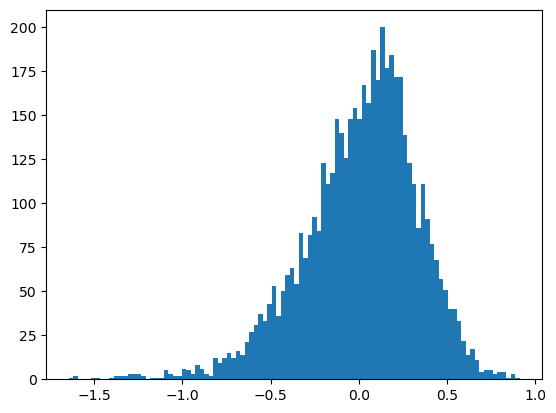

In [19]:
import matplotlib.pyplot as plt
plt.hist(logit_preds[:, 769], bins=100)

In [15]:
sl = len(test_prot['seq'])
aa_str = 'LAGVSERTIDPKQNFYMHWC'
aa_ind = [tokenizer.get_vocab()[c] for c in aa_str]
bert_distr = bert_distr[1:sl+1, aa_ind]
bert_distr /= bert_distr.sum(dim=1, keepdim=True)
bert_logits = torch.log(bert_distr)

def to_seqf_tok(tok, sl):
    return tok[:, 1:sl+1] - 4 #-4 to convert to pure aa tokens from BERT tokens

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

mut_seq_tok = torch.cat([batch['seq_ind'] for batch in mut_dl])
mut_seq_tok = to_seqf_tok(mut_seq_tok, sl).to(device)
mut_seq_target_logit = logit_preds[:, 769]
joint_logits = torch.stack([torch.zeros_like(mut_seq_target_logit), mut_seq_target_logit], dim=-1)
mut_seq_target_log = torch.log_softmax(joint_logits, dim=-1)
# mut_seq_target_log = F.logsigmoid(mut_seq_target_logit)

In [13]:
#Bayes net
#P(Seq) = P(Seq | F) P(F) + P(Seq | ~F) P(~F)
#P(F|Seq) = P(Seq | F) P(F) / P(Seq) = = P(Seq | F) P(F) / [P(Seq | F) P(F) + P(Seq | ~F) P(~F)]

class SeqFBayes(nn.Module):
    def __init__(self, base_logits):
        super().__init__()
        self.pos_logit = torch.nn.Parameter(base_logits.clone())
        self.neg_logit = torch.nn.Parameter(base_logits.clone())
        self.base_logit = base_logits
        self.logit_prior = torch.nn.Parameter(torch.tensor([0.0, 0.0]))
    
    def forward(self, seq):
        log_prior = F.log_softmax(self.logit_prior, dim=0)
        ln, v = self.base_logit.shape
        pos_logprob = torch.log_softmax(self.pos_logit, dim=1)[torch.arange(ln).reshape(1, -1), seq].sum(dim=1)
        neg_logprob = torch.log_softmax(self.neg_logit, dim=1)[torch.arange(ln).reshape(1, -1), seq].sum(dim=1)
        joint_logprob = torch.stack([pos_logprob + log_prior[0], neg_logprob + log_prior[1]], dim=-1)
        base_logprob = torch.logsumexp(joint_logprob, dim=-1)
        # print(log_prior)
        # print(base_logprob[0].item(), (pos_logprob[0].item(), neg_logprob[0].item()))
        pos_cond_prob = pos_logprob + log_prior[0] - base_logprob
        neg_cond_prob = neg_logprob + log_prior[1] - base_logprob
        # print('cond prob', cond_prob[0].item())
        return torch.stack([neg_cond_prob, pos_cond_prob], dim=-1)
    
model = SeqFBayes(bert_logits).to(device)
mut_seq_tok = mut_seq_tok.to(device)
mut_seq_target_log = mut_seq_target_log.to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=3e-4)
loss_fn = nn.KLDivLoss(log_target=True, reduction='batchmean')
# train_seqf(model, loss_fn, optimizer, mut_seq_tok, mut_seq_target_log)

from collections import defaultdict
run_data = defaultdict(list)

for epoch in range(500):
    logprob = model.forward(mut_seq_tok) # N x C
    # print(logprob.shape)
    # seq_loss = F.kl_div(logprob, mut_seq_target_log, log_target=True, reduction='batchmean')
    seq_loss = F.kl_div(logprob, mut_seq_target_log, log_target=True, reduction='batchmean')

    reg_loss = (F.kl_div(torch.log_softmax(model.pos_logit, dim=1), 
                     torch.log_softmax(model.base_logit, dim=1), 
                     log_target=True, reduction='sum') + 
                    F.kl_div(torch.log_softmax(model.neg_logit, dim=1), 
                     torch.log_softmax(model.base_logit, dim=1), 
                     log_target=True, reduction='sum')
                    )
    loss = seq_loss + 1e-1*reg_loss
    # run_data['target_prob'].append(mut_seq_target_log[ 0, 1].item())
    # run_data['cond_prob'].append(logprob[0, 1].item())
    run_data['seq_loss'].append(seq_loss.item())
    run_data['reg_loss'].append(1e2*reg_loss.item())
    # loss = seq_loss
    # print(seq_loss.cpu().item(), reg_loss.cpu().item())
    # print(logprob.max().item(), logprob.min().item(), mut_seq_target_log.max().item(), mut_seq_target_log.min().item())
    # print(loss.cpu().item())
    # print('kl div', F.kl_div(model.cond_logit, model.base_logit, log_target=True, reduction='batchmean').cpu().item())
    # print(model.cond_logit[0, 0])
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# model = SeqFBayes(bert_logits).to(device)
# mut_seq_tok = mut_seq_tok.to(device)
# mut_seq_target_log = mut_seq_target_log.to(device)
# log_preds = model.forward(mut_seq_tok)

In [26]:
mdelta = (torch.softmax(model.pos_logit, -1) - torch.softmax(model.base_logit, -1)).detach().cpu()
delta_scores = mdelta.max(dim=-1).values

In [29]:
test_prot['annot_ind']

[249, 268]

In [34]:
base_distr = torch.softmax(model.base_logit, -1).detach().cpu()
seq_entropy = -(base_distr*torch.log(base_distr)).sum(dim=1)
base_sort_ind = torch.argsort(seq_entropy, descending=False)
print(base_sort_ind)

tensor([267, 246, 203, 244, 239,   0, 199, 245, 243, 242, 250, 279, 253, 257,
        268, 265, 266, 227, 249, 248, 254, 211, 264, 204, 235, 255, 251, 270,
        195, 140, 215, 263, 144, 258, 224, 247, 259, 212, 191, 202, 256, 234,
        187, 161, 274, 298, 276, 252, 213, 233, 193, 269, 208, 241, 302, 200,
        198, 237, 196, 271, 207, 189,  11, 186, 141, 185, 261, 238, 149, 197,
        214, 240, 158, 192, 273,  87, 231, 184, 201, 127, 157, 190, 337, 280,
        146, 153,  74, 181, 220, 335, 225, 236,  90, 217, 145, 210, 216, 226,
          7, 206,   1, 194, 148, 143, 182, 183,  10, 150, 277,  95,  93, 229,
        166,  22, 160, 313, 339, 228,   2, 336,  17,  46,  76, 171, 272, 176,
         15,  21, 124, 300, 333, 205, 209, 301, 342, 156,  19,  25, 334,  16,
         14,  23,  24, 122, 278,   9,  18, 275, 343,  97, 260, 296,   3,  20,
          8,  54,   6, 232, 168,  38,   5, 311, 163, 222,  12, 340, 332,  29,
        330, 119, 152, 317,  98, 230,  43, 338,  27, 136,  96, 1

In [35]:
sort_ind = torch.argsort(torch.abs(delta_scores), descending=True)

tensor([251, 248,   0, 265, 243, 255, 253, 225, 246, 250, 166,  92, 245, 257,
        247, 266, 263, 249, 234, 276, 258, 295, 239, 244,  13, 220, 221, 224,
         93, 259, 242,  95,  26,  41,  19, 256, 199,   9,  10, 165, 252, 191,
         38, 228, 207,  99,  66, 195,  16,   2,  15, 282, 343, 111,  36, 314,
        226, 342, 261,  94, 102,  29, 337,   4, 320, 147,  59, 114, 334,   3,
         60,  45,   1, 223, 283,  39, 206,  67, 329, 300, 198,  78,  27, 227,
         57, 236, 138,  14, 240, 170, 141, 272,   5,  61,  72,  53, 318,  52,
        319,  22, 262, 307, 196, 235,  44,  11, 292, 186, 212, 105,  85, 303,
        154, 311,  32, 297, 150, 130,  48,  96, 127, 333,   8, 271,  25,   7,
        205, 123, 281, 107, 131, 187, 132, 289, 336, 173, 338, 325, 218, 323,
         12, 162, 168, 208, 296, 181, 137, 339, 124, 260,  42,  64, 284,  50,
        113, 104,  17, 328, 341,  43, 231, 233, 286,  47,  28,  75, 312, 310,
        215, 278,  33, 175, 152,  70, 216, 285, 202,  49, 335, 1

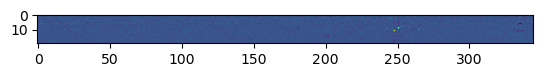

In [19]:
mdelta = (torch.softmax(model.pos_logit,-1).detach().cpu().numpy() - torch.softmax(model.base_logit,-1).detach().cpu().numpy())
plt.imshow(mdelta.T)

In [20]:
print(np.max(mdelta), np.min(mdelta))

0.010855913 -0.00384143


In [70]:
print(test_prot['annot_ind'])

[249, 268]


In [58]:
tokenizer.get_vocab()
SEQUENCE_VOCAB = [None]*len(tokenizer.get_vocab())
for k, i in tokenizer.get_vocab().items():
    SEQUENCE_VOCAB[i] = k

In [64]:
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
import numpy as np

import bokeh.plotting
bokeh.io.output_notebook()
from bokeh.models import BasicTicker, PrintfTickFormatter
from bokeh.palettes import viridis, RdBu
from bokeh.transform import linear_cmap
from bokeh.plotting import figure, show

from matplotlib.colors import to_hex
cmap = plt.colormaps["bwr_r"]
bwr_r = [to_hex(cmap(i)) for i in np.linspace(0, 1, 256)]
cmap = plt.colormaps["gray_r"]
gray = [to_hex(cmap(i)) for i in np.linspace(0, 1, 256)]

esm_alphabet = SEQUENCE_VOCAB[4:24]
ALPHABET = "AFILVMWYDEKRHNQSTGPC"
ALPHABET_map = [esm_alphabet.index(a) for a in ALPHABET]

def pssm_to_dataframe(pssm, esm_alphabet):
  sequence_length = pssm.shape[0]
  idx = [str(i) for i in np.arange(1, sequence_length + 1)]
  df = pd.DataFrame(pssm, index=idx, columns=list(esm_alphabet))
  df = df.stack().reset_index()
  df.columns = ['Position', 'Amino Acid', 'Probability']
  return df

pssm = torch.softmax(model.pos_logit[150:-30],-1).detach().cpu().numpy()
df = pssm_to_dataframe(pssm, ALPHABET)
sequence = test_prot['seq'][150:-30]

# plot pssm
num_colors = 256  # You can adjust this number
palette = viridis(256)
TOOLS = "hover,save,pan,box_zoom,reset,wheel_zoom"
p = figure(title="CONSERVATION",
           x_range=[str(x) for x in range(1,len(sequence)+1)],
           y_range=list(ALPHABET)[::-1],
           width=900, height=400,
           tools=TOOLS, toolbar_location='below',
           tooltips=[('Position', '@Position'), ('Amino Acid', '@{Amino Acid}'), ('Probability', '@Probability')])

r = p.rect(x="Position", y="Amino Acid", width=1, height=1, source=df,
           fill_color=linear_cmap('Probability', palette, low=0, high=1),
           line_color=None)
p.xaxis.visible = False  # Hide the x-axis
show(p)

Loading BokehJS ...

In [66]:
pssm = torch.softmax(model.pos_logit[150:-30],-1).detach().cpu().numpy() - torch.softmax(model.base_logit[150:-30],-1).detach().cpu().numpy()
df = pssm_to_dataframe(pssm, ALPHABET)
sequence = test_prot['seq'][150:-30]

# plot pssm
num_colors = 256  # You can adjust this number
palette = viridis(256)
TOOLS = "hover,save,pan,box_zoom,reset,wheel_zoom"
p = figure(title="CONSERVATION",
           x_range=[str(x) for x in range(1,len(sequence)+1)],
           y_range=list(ALPHABET)[::-1],
           width=900, height=400, 
           tools=TOOLS, toolbar_location='below',
           tooltips=[('Position', '@Position'), ('Amino Acid', '@{Amino Acid}'), ('Probability', '@Probability')])

r = p.rect(x="Position", y="Amino Acid", width=1, height=1, source=df,
           fill_color=linear_cmap('Probability', palette, low=0, high=1),
           line_color=None)
p.xaxis.visible = False  # Hide the x-axis
show(p)

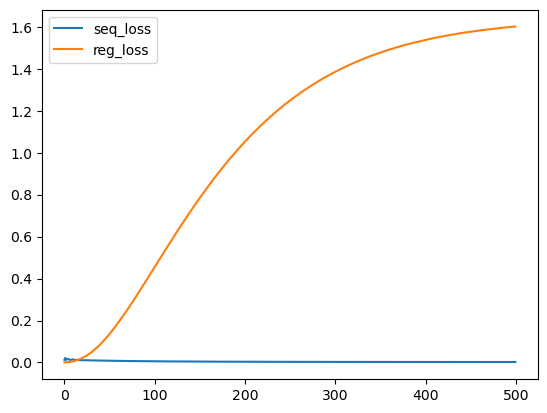

In [14]:
import matplotlib.pyplot as plt
for k in run_data:
    plt.plot(run_data[k], label=k)
plt.legend()
plt.show()

In [15]:
print(np.square(logprob.detach().cpu().numpy()[:, 1] - mut_seq_target_log.detach().cpu().numpy()[:, 1]).mean())

0.0055356235


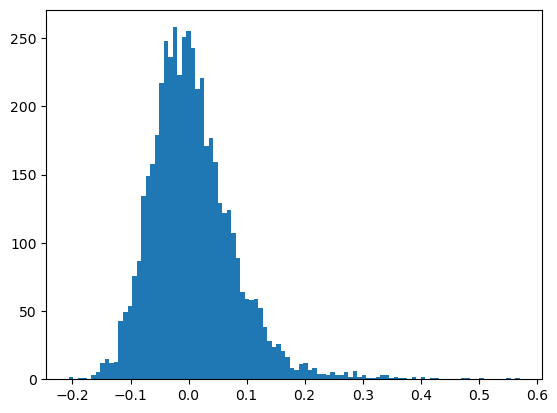

In [16]:
plt.hist(logprob.detach().cpu().numpy()[:, 1] - mut_seq_target_log.detach().cpu().numpy()[:, 1], bins=100)
plt.show()

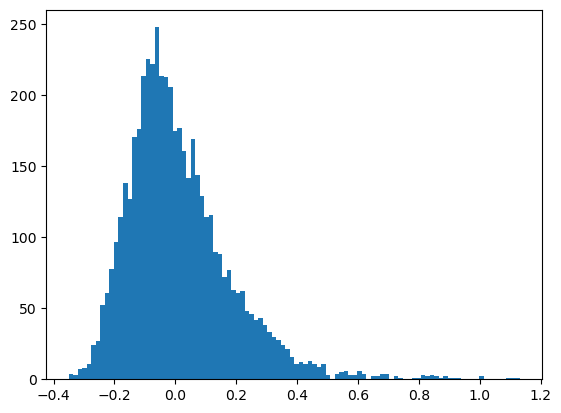

In [52]:
plt.hist(logprob.detach().cpu().numpy()[:, 1] - mut_seq_target_log.detach().cpu().numpy()[:, 1], bins=100)
plt.show()

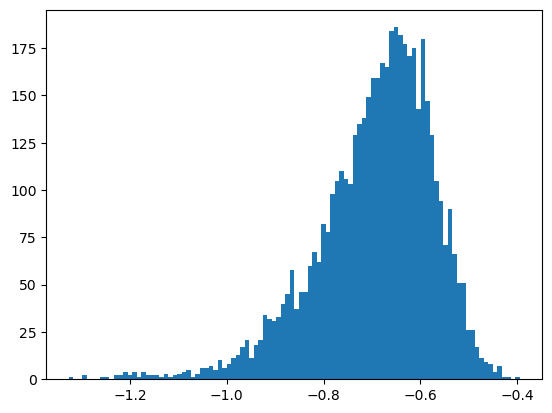

In [17]:
plt.hist(logprob.detach().cpu().numpy()[:, 1], bins=100)
plt.show()

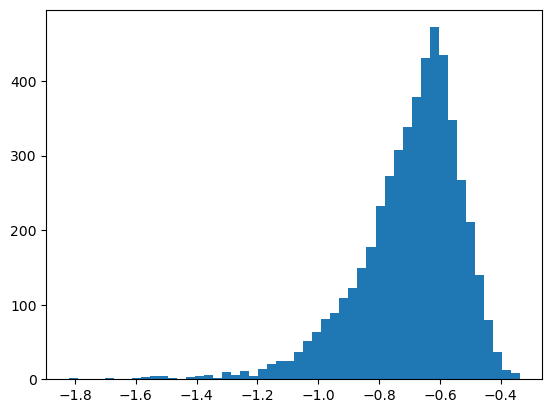

In [18]:
plt.hist(mut_seq_target_log.cpu().numpy()[:, 1], bins=50)
plt.show()

In [13]:
def train_seqf(model, loss_fn, optimizer, tok, target_log, epochs=100):
    for epoch in range(1000):
        logprob = model.forward(tok)
        # print(logprob.max(), logprob.min(), target_log.max(), target_log.min())
        seq_loss = F.kl_div(logprob, target_log, log_target=True, reduction='batchmean')
        reg_loss = 1e2*F.kl_div(torch.log_softmax(model.cond_logit, dim=1), 
                         torch.log_softmax(model.base_logit, dim=1), 
                         log_target=True, reduction='sum')
        loss = seq_loss + reg_loss
        # loss = seq_loss
        print(seq_loss.cpu().item(), reg_loss.cpu().item())
        print(loss.cpu().item())
        # print('kl div', F.kl_div(model.cond_logit, model.base_logit, log_target=True, reduction='batchmean').cpu().item())
        # print(model.cond_logit[0, 0])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

In [16]:
print(logprob)

tensor([25.2643, 25.1643, 24.8643,  ..., 25.3643, 25.3643, 25.5643],
       device='cuda:0', grad_fn=<AddBackward0>)


In [97]:
print(model.cond_logit - model.base_logit)

tensor([[ 0.0265,  0.0265,  0.0265,  ...,  0.0265,  0.0265,  0.0265],
        [-0.0047, -0.0047, -0.0047,  ..., -0.0047, -0.0047, -0.0047],
        [ 0.0279,  0.0279,  0.0279,  ...,  0.0279,  0.0279,  0.0279],
        ...,
        [-0.0159, -0.0159, -0.0159,  ..., -0.0159, -0.0159, -0.0159],
        [-0.0188, -0.0188, -0.0188,  ..., -0.0188, -0.0188, -0.0188],
        [ 0.0226,  0.0226,  0.0225,  ...,  0.0226,  0.0226,  0.0226]],
       device='cuda:0', grad_fn=<SubBackward0>)


In [8]:
import json
train_path = "/home/andrew/cafa5_team/data/"
with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
    go_terms = json.load(f)
term_ind_map = {t:i for i, t in enumerate(go_terms)}
import goatools
from goatools.obo_parser import GODag
godag = GODag('../go-basic.obo')
from goatools.godag.go_tasks import get_go2parents
optional_relationships = set()
go2parents_isa = get_go2parents(godag, optional_relationships)

def get_parent_inds(go_ind):
    go_term = go_terms[go_ind]
    if(not go_term in go2parents_isa):
        return go_ind    
    parents = go2parents_isa[go_term]
    parent_inds = [term_ind_map[p] for p in parents if p in term_ind_map]
    return parent_inds

../go-basic.obo: fmt(1.2) rel(2024-04-24) 45,667 Terms


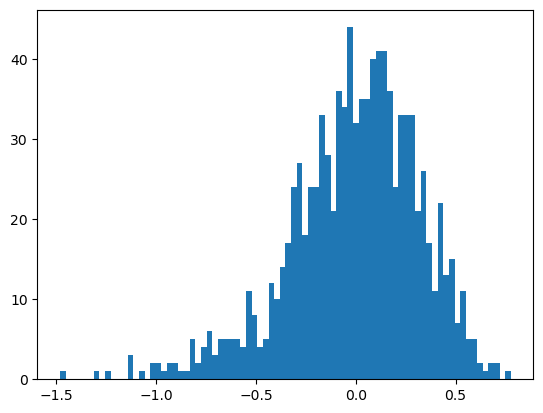

In [11]:
import matplotlib.pyplot as plt
plt.hist(logit_preds[:, 769].cpu().numpy(), bins=80)
plt.show()

[1781, 769]


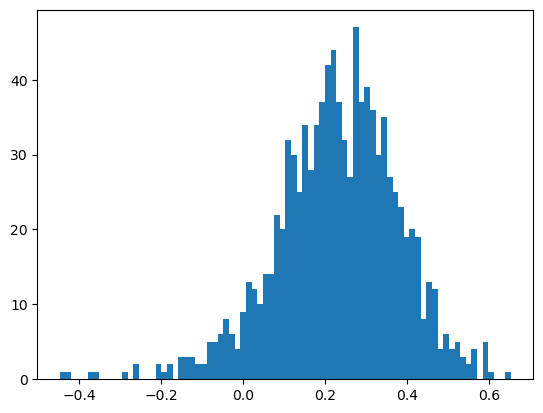

In [29]:
import matplotlib.pyplot as plt

parent_inds = get_parent_inds(test_prot['go_ind'])
print(parent_inds)
logit_preds[:, parent_inds]

plt.hist(logit_preds[:, 769].cpu().numpy(), bins=80)
plt.show()

In [ ]:
godag[go_terms[769]]

In [19]:
logit_preds[:, 805]
go_ind = test_prot['go_ind']

tensor([-5.5372, -5.4233, -5.2665, -5.4183, -5.5657, -5.6076, -5.2407, -5.3785,
        -5.5159, -5.3221, -5.4107, -5.5418, -5.5135, -5.3185, -5.5216, -5.3177,
        -5.4865, -5.2005, -5.3454, -5.3873, -5.4870, -5.4382, -5.3765, -5.2467,
        -5.3414, -5.4275, -5.5693, -5.4681, -5.5871, -5.4504, -5.4277, -5.3564,
        -5.2853, -5.3761, -5.3259, -5.4848, -5.2351, -5.3082, -5.6171, -5.3256,
        -5.3943, -5.4536, -5.4055, -5.4638, -5.3460, -5.3849, -5.3746, -5.3805,
        -5.3987, -5.3202, -5.2833, -5.1940, -5.3409, -5.3395, -5.5854, -5.2961,
        -5.3323, -5.4601, -5.4635, -5.3754, -5.6076, -5.5335, -5.4404, -5.5021,
        -5.5932, -5.4020, -5.3164, -5.6452, -5.3732, -5.4311, -5.2570, -5.5880,
        -5.2090, -5.1677, -5.2978, -5.4897, -5.0845, -5.5357, -5.4243, -5.1951,
        -5.5462, -5.4592, -5.4720, -5.3941, -5.3698, -5.4727, -5.3656, -5.5099,
        -5.4942, -5.3915, -5.1426, -5.1553, -5.5388, -5.3376, -5.3265, -5.3410,
        -5.4857, -5.4546, -5.4230, -5.42

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERTFinetune(
  (model): EsmModel(
    (embeddings): EsmEmbeddings(
      (word_embeddings): Embedding(33, 1280, padding_idx=1)
      (dropout): Dropout(p=0.0, inplace=False)
      (position_embeddings): Embedding(1026, 1280, padding_idx=1)
    )
    (encoder): EsmEncoder(
      (layer): ModuleList(
        (0-32): 33 x EsmLayer(
          (attention): EsmAttention(
            (self): EsmSelfAttention(
              (query): Linear(in_features=1280, out_features=1280, bias=True)
              (key): Linear(in_features=1280, out_features=1280, bias=True)
              (value): Linear(in_features=1280, out_features=1280, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
              (rotary_embeddings): RotaryEmbedding()
            )
            (output): EsmSelfOutput(
              (dense): Linear(in_features=1280, out_features=1280, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (LayerNorm): LayerNorm((1280,), eps=1e-05, 

In [5]:
def mean_reciprocal_rank(token_attribution, conserved_tokens):
    token_attribution =  token_attribution #- 1e5*(token_attribution == 0) #Ignore padding
    attribution_argsort = torch.argsort(token_attribution, dim=1, descending=True)
    attribution_ranks = torch.argsort(attribution_argsort, dim=1, descending=False)
    ttr = 0
    tct = 0
    for i, token_ind in enumerate(conserved_tokens):
        token_ranks = attribution_ranks[i, token_ind]
        ttr += torch.divide(1, token_ranks+1).sum()
        tct += token_ranks.shape[0]
    return ttr / tct
print(mean_reciprocal_rank(bert_attr, enzyme_df['AnnotatedIndices']))

def mean_percent_rank(token_attribution, seq_len, conserved_tokens):
    token_mask = torch.tile(torch.arange(0, 1024).reshape(1, -1), (token_attribution.shape[0], 1))
    token_mask[:, 0] += 1024
    token_mask = token_mask < seq_len.reshape(-1, 1)
    token_attribution =  token_attribution.clone() - 1e5*(~token_mask)
    attribution_argsort = torch.argsort(token_attribution, dim=1, descending=True)
    attribution_ranks = torch.argsort(attribution_argsort, dim=1, descending=False)
    attribution_percent_rank = attribution_ranks / seq_len.reshape(-1, 1)
    ttr = 0
    tct = 0
    for i, token_ind in enumerate(conserved_tokens):
        # print(token_ind)
        token_ranks = attribution_percent_rank[i, token_ind]
        # print(token_ranks)
        ttr += token_ranks.sum()
        tct += token_ranks.shape[0]
    return ttr / tct
print(mean_percent_rank(bert_attr, seq_len, enzyme_df['AnnotatedIndices']))

tensor(0.1364)
tensor(0.1892)


In [11]:
from go_ml.aa_params import aromatic_scale, pKs_scale, gravy_scale, protein_weight_scale
from sklearn.preprocessing import StandardScaler
import numpy as np

def residue_emb(sequence, key_ind):
    sequence_embeddings_list = []
    for ri in key_ind:
        r = sequence[ri]
        sequence_embeddings_list.append([aromatic_scale[r], pKs_scale[r], gravy_scale[r], protein_weight_scale[r]])
    sequence_embeddings = np.array(sequence_embeddings_list)
    return sequence_embeddings

seq_emb_l = []
for ed in enzyme_iterator():
    seq = ed['seq']
    key_ind = np.arange(len(seq))
    seq_emb = residue_emb(seq, key_ind)
    seq_emb_l.append(seq_emb)
res_emb = np.concatenate(seq_emb_l, axis=0)
residue_scaler = StandardScaler().fit(res_emb)

res_emb.shape

(339024, 4)

In [12]:
import goatools
from goatools.obo_parser import GODag
godag = GODag('../go-basic.obo')
from goatools.godag.go_tasks import get_go2parents
optional_relationships = set()
go2parents_isa = get_go2parents(godag, optional_relationships)
from goatools.gosubdag.gosubdag import GoSubDag

gosubdag_r0 = GoSubDag(['GO:0018683'], godag, prt=None)
go_ancestors = gosubdag_r0.rcntobj.go2ancestors['GO:0018683']
go_ancestors.add('GO:0018683')

def get_parent_ind(go_ind):
    go_term = go_terms[go_ind]
    if(not go_term in go2parents_isa):
        return go_ind    
    parents = go2parents_isa[go_term]
    if(len(parents) == 0):
        return go_ind
    parent_inds = [term_ind_map[p] for p in parents if p in term_ind_map]
    if(len(parent_inds) == 0):
        return go_ind
    return parent_inds[0]

def get_ancestor_ind(go_ind):
    go_term = go_terms[go_ind]
    if(not go_term in godag):
        return []
    gosubdag_r0 = GoSubDag([go_term], godag, prt=None)
    go_ancestors = gosubdag_r0.rcntobj.go2ancestors[go_term]
    go_ancestors.add(go_term)
    ancestor_ind = [term_ind_map[anc] for anc in go_ancestors if anc in term_ind_map]
    return ancestor_ind

../go-basic.obo: fmt(1.2) rel(2024-04-24) 45,667 Terms


In [13]:
go2parents_isa['GO:0018683']

{'GO:0016713'}

In [16]:
mut_residue_emb_l = []
for i, r in enumerate(enzyme_iterator()):
    key_ind = top_k_ind[i]
    prot_mut_l = mut_sequences[i*100:i*100+100]
    mut_residue_emb = []
    for pm in prot_mut_l:
        mut_residue_emb.append(residue_scaler.transform(residue_emb(pm, key_ind)))
    mut_residue_emb = np.array(mut_residue_emb)
    mut_residue_emb_l.append(mut_residue_emb)

In [17]:
go_terms[20]
godag['GO:0005739'].depth

5

In [21]:
print(mut_residue_emb[0].shape)

(75, 4)


In [20]:
from sklearn.linear_model import LinearRegression
lime_models = []
for i, r in enumerate(enzyme_iterator()):
    go_ind = r['go_ind']
    coef = np.zeros(mut_residue_emb[0].shape)
    mut_residue_emb = mut_residue_emb_l[i]
    local_pred = model_evals[i*100:i*100 + 100, go_ind].toarray().flatten()
    if(local_pred.sum()==0):
        go_ind = get_parent_ind(go_ind)
        local_pred = model_evals[i*100:i*100 + 100, go_ind].toarray().flatten()
    mut_inp = mut_residue_emb.reshape((100, -1))
    lime_model = LinearRegression()
    lime_model.fit(mut_inp, local_pred)
    coef += lime_model.coef_.reshape(mut_residue_emb[0].shape)
    lime_models.append(coef)

0 [[[-0.31167322 -0.97068433 -1.0781843   0.15037783]
  [-0.31167322 -0.0694858   0.70484542  0.70919281]
  [-0.31167322 -0.0694858  -0.05459317 -1.86292204]
  ...
  [-0.31167322 -1.05969159 -1.0781843   0.63696725]
  [-0.31167322 -0.0694858  -0.45082199 -0.47308632]
  [-0.31167322 -0.0694858   1.33220772  0.08343215]]

 [[-0.31167322 -0.97068433 -1.0781843   0.15037783]
  [-0.31167322 -0.0694858   0.70484542  0.70919281]
  [-0.31167322 -0.0694858  -0.05459317 -1.86292204]
  ...
  [ 3.20848872 -0.0694858   1.00201703  1.26347028]
  [-0.31167322 -0.0694858  -0.18666944 -0.82130584]
  [-0.31167322 -0.0694858  -0.45082199 -0.47308632]]

 [[-0.31167322 -0.97068433 -1.0781843   0.15037783]
  [-0.31167322 -0.0694858   1.5633412   0.08343215]
  [-0.31167322 -0.0694858  -0.05459317 -1.86292204]
  ...
  [-0.31167322 -1.05969159 -1.0781843   0.63696725]
  [-0.31167322 -0.0694858  -0.18666944 -0.82130584]
  [-0.31167322 -0.0694858   0.67182635 -1.37633262]]

 ...

 [[-0.31167322 -0.97068433 -1.07

In [21]:
lime_coef_attr = np.zeros((len(enzyme_df), 1024, 4))
for i, r in enumerate(enzyme_iterator()):
    key_ind = top_k_ind[i]
    lime_coef = lime_models[i]
    lime_coef_attr[i, key_ind+1, :] = lime_coef

In [22]:
lime_abs_attr = torch.tensor(np.sum(np.abs(lime_coef_attr), axis=2)) - 1e9*(~enzyme_mask)
print(mean_percent_rank(lime_abs_attr, seq_len, enzyme_df['AnnotatedIndices']))
print(mean_reciprocal_rank(lime_abs_attr, enzyme_df['AnnotatedIndices']))

tensor(0.2707)
tensor(0.0622)


In [23]:
nonkey_mask = np.ones(lime_abs_attr.shape, dtype=bool)
nonkey_mask[:, top_k_ind+1] = False
lime_abs_attr = lime_abs_attr + bert_attr*nonkey_mask
print(mean_percent_rank(lime_abs_attr, seq_len, enzyme_df['AnnotatedIndices']))

tensor(0.2703)


In [24]:
print(bert_attr[0])

tensor([-1.0000e+09, -4.8966e-03, -1.2917e+00,  ..., -1.0000e+09,
        -1.0000e+09, -1.0000e+09])


In [25]:
b = bert_attr[0]
b[b< -1e3] = 0
b -= b.min()
print(b[top_k_ind[0]])

# is a reference so now bert_attr[0] is altered

tensor([1.3125, 2.7857, 1.6954, 0.7530, 0.4572, 0.7482, 1.6162, 1.0488, 0.9962,
        1.5136, 1.7813, 1.2838, 1.4549, 1.0706, 1.0216, 1.5909, 0.8425, 1.5584,
        1.6227, 1.3786, 0.6977, 0.6416, 1.1643, 1.2421, 0.8403, 0.4897, 1.7304,
        2.3420, 1.1399, 0.3563, 2.1493, 0.4884, 0.9010, 1.4940, 0.9459, 2.0242,
        1.7193, 0.7060, 2.4770, 1.7432, 2.5802, 0.4476, 1.3632, 2.1750, 1.0379,
        0.8182, 1.3247, 1.7490, 0.5181, 0.7123, 1.2443, 0.5858, 2.6312, 0.3677,
        1.0253, 2.7289, 0.7732, 0.8330, 0.5039, 1.5292, 0.5737, 2.3072, 2.3221,
        0.6860, 1.1438, 2.7559, 0.4312, 0.9586, 0.2137, 0.8232, 1.7889, 1.0542,
        0.7836, 0.7050, 0.6276])


[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0.]


/tmp/ipykernel_3522314/1233348315.py:52: RuntimeWarning: invalid value encountered in divide
  f'LIME Other GO ({go_term_other})': np.abs(other_GO_model_coef[0][top_k_ind[i]]).sum(axis=-1) / np.max(np.abs(other_GO_model_coef[0]).sum(axis=-1))


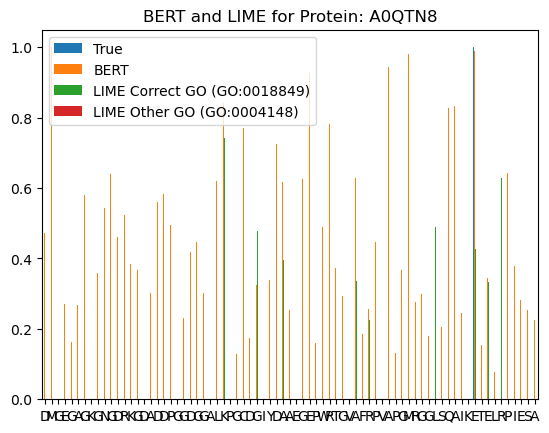

<Figure size 1500x800 with 0 Axes>

In [26]:
# figure 

# random GO terms
i = 0
r = next(enzyme_iterator())
seq = r['seq']
AA = [seq[n] for n in top_k_ind[i]]

true_importance = np.zeros(1024)
true_importance[annotated_indices[0]] = 1


correct_GO_model_coef = np.zeros((1, 1024, 4))
go_ind = r['go_ind']
go_term_correct = go_terms[go_ind]
coef = np.zeros(mut_residue_emb[0].shape)
mut_residue_emb = mut_residue_emb_l[i]
local_pred = model_evals[i*100:i*100 + 100, go_ind].toarray().flatten()
if(local_pred.sum()==0):
    go_ind = get_parent_ind(go_ind)
    local_pred = model_evals[i*100:i*100 + 100, go_ind].toarray().flatten()
mut_inp = mut_residue_emb.reshape((100, -1))
lime_model = LinearRegression()
lime_model.fit(mut_inp, local_pred)
coef += lime_model.coef_.reshape(mut_residue_emb[0].shape)
correct_GO_model_coef[0, key_ind+1, :] = coef

random_go_ind = np.random.choice(1000, 1, replace=False)
go_ind = go_ind + random_go_ind
go_ind = go_ind[0]
go_term_other = go_terms[go_ind]
other_GO_model_coef = np.zeros((1, 1024, 4))
coef = np.zeros(mut_residue_emb[0].shape)
mut_residue_emb = mut_residue_emb_l[i]
local_pred = model_evals[i*100:i*100 + 100, go_ind].toarray().flatten()
if(local_pred.sum()==0):
    go_ind = get_parent_ind(go_ind)
    local_pred = model_evals[i*100:i*100 + 100, go_ind].toarray().flatten()
mut_inp = mut_residue_emb.reshape((100, -1))
other_GO = LinearRegression()
other_GO.fit(mut_inp, local_pred)
coef += other_GO.coef_.reshape(mut_residue_emb[0].shape)
other_GO_model_coef[0, key_ind+1, :] = coef

print(np.abs(other_GO_model_coef[0][top_k_ind[i]]).sum(axis=-1))
print(true_importance[top_k_ind[0]])

df=pd.DataFrame({
    'True': true_importance[top_k_ind[0]],
    'BERT': bert_attr[i][top_k_ind[i]] / torch.max(bert_attr[i]), 
    f'LIME Correct GO ({go_term_correct})': np.abs(correct_GO_model_coef[0][top_k_ind[i]]).sum(axis=-1) / np.max(np.abs(correct_GO_model_coef[0]).sum(axis=-1)), 
    f'LIME Other GO ({go_term_other})': np.abs(other_GO_model_coef[0][top_k_ind[i]]).sum(axis=-1) / np.max(np.abs(other_GO_model_coef[0]).sum(axis=-1))
}, index=AA)
df.plot.bar(rot=0)
plt.title(f"BERT and LIME for Protein: {r["prot_id"]}")
plt.figure(figsize=(15,8))
plt.show()

[1.29415949 0.65797858 0.79114197 0.52817475 1.56478782 0.        ]
[0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0.]


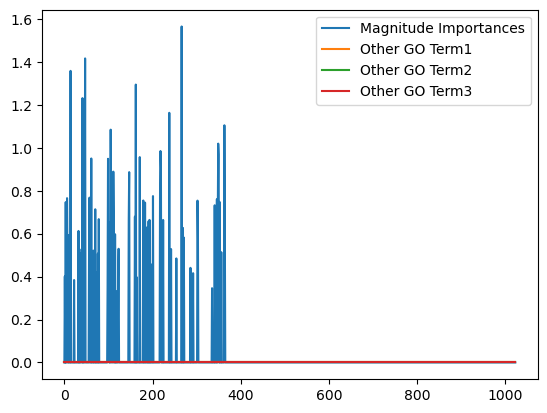

In [27]:
# test run with just one protein
r = next(enzyme_iterator())
random_go_inds = np.random.choice(1000, 3, replace=False)
random_go_terms = [go_terms[i] for i in random_go_inds]
go_true = r['go_ind']
go_inds = [r['go_ind']] + random_go_inds
go_inds = np.append(go_true, go_inds)
i = 0

first_protein_models = []
for ind in go_inds:
    go_ind = ind
    coef = np.zeros(mut_residue_emb[0].shape)
    mut_residue_emb = mut_residue_emb_l[i]
    local_pred = model_evals[i*100:i*100 + 100, go_ind].toarray().flatten()
    if(local_pred.sum()==0):
        go_ind = get_parent_ind(go_ind)
        local_pred = model_evals[i*100:i*100 + 100, go_ind].toarray().flatten()
    mut_inp = mut_residue_emb.reshape((100, -1))
    lime_model = LinearRegression()
    lime_model.fit(mut_inp, local_pred)
    coef += lime_model.coef_.reshape(mut_residue_emb[0].shape)
    first_protein_models.append(coef)

lime_coef_attr = np.zeros((len(go_inds), 1024, 4))
for i, r in enumerate(go_inds):
    key_ind = top_k_ind[0]
    lime_coef = first_protein_models[i]
    lime_coef_attr[i, key_ind+1, :] = lime_coef

for i in range(len(go_inds)):
    sum = np.abs(lime_coef_attr[i]).sum(axis=-1)
    print(sum[annotated_indices[0]])


plt.plot(np.abs(lime_coef_attr[0]).sum(axis=-1), label='Magnitude Importances')
for i in range(1, len(go_inds)):
    go_term_label = f'Other GO Term{i}'
    plt.plot(np.abs(lime_coef_attr[i]).sum(axis=-1), label=go_term_label)
true_importance = np.zeros(1024)
true_importance[annotated_indices[0]] = 1

plt.legend()
plt.show()

[0.9404328  1.2686481  1.60226592 1.08844529 1.65708771 0.        ]


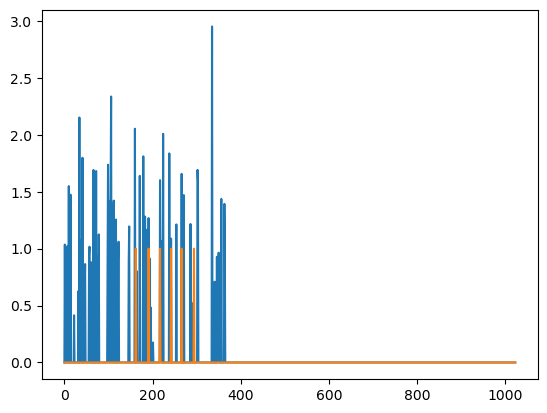

In [30]:
# this is for 1000 samples

from sklearn.linear_model import LinearRegression

with open('/home/andrew/GO_interp/data/first_enzyme_mut_evals.pkl', 'rb') as f:
    mut_seq_dataset, model_evals = pickle.load(f)

r = next(enzyme_iterator())

model_evals = csr_matrix(model_evals)
mut_sequences = mut_seq_dataset['seq']

mut_residue_emb_l = []
key_ind = top_k_ind[0]
prot_mut_l = mut_sequences  
mut_residue_emb = []
for pm in prot_mut_l:
    mut_residue_emb.append(residue_scaler.transform(residue_emb(pm, key_ind)))
mut_residue_emb = np.array(mut_residue_emb)
mut_residue_emb_l.append(mut_residue_emb)



first_protein_coef = np.zeros((1, 1024, 4))
go_ind = r['go_ind']
go_term_correct = go_terms[go_ind]
coef = np.zeros(mut_residue_emb[0].shape)
mut_residue_emb = mut_residue_emb_l[0]
local_pred = model_evals[:, go_ind].toarray().flatten()
if(local_pred.sum()==0):
    go_ind = get_parent_ind(go_ind)
    local_pred = model_evals[:, go_ind].toarray().flatten()
mut_inp = mut_residue_emb.reshape((1000, -1))
lime_model = LinearRegression()
lime_model.fit(mut_inp, local_pred)
coef += lime_model.coef_.reshape(mut_residue_emb[0].shape)
first_protein_coef[0, key_ind+1, :] = coef

mag = np.abs(first_protein_coef[0]).sum(axis=-1)
true_importance = np.zeros(1024)
true_importance[annotated_indices[0]] = 1

plt.plot(mag)
plt.plot(true_importance)

print(mag[true_importance == 1])

[1.64611015 0.47010545 1.3514653  0.76542847 1.44932556 0.        ]


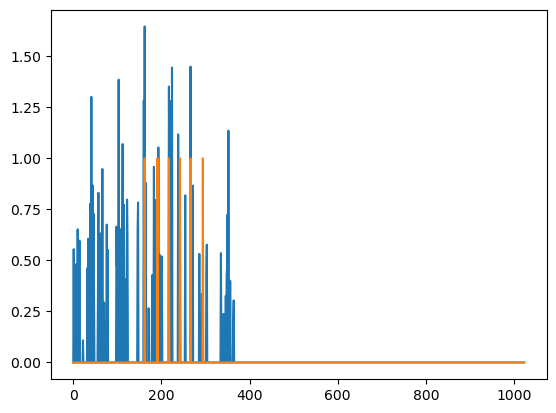

In [31]:
from sklearn.linear_model import LinearRegression

with open('/home/andrew/GO_interp/data/first_enzyme_5000_mut_evals.pkl', 'rb') as f:
    mut_seq_dataset, model_evals = pickle.load(f)

r = next(enzyme_iterator())

model_evals = csr_matrix(model_evals)
mut_sequences = mut_seq_dataset['seq']

mut_residue_emb_l = []
key_ind = top_k_ind[0]
prot_mut_l = mut_sequences  
mut_residue_emb = []
for pm in prot_mut_l:
    mut_residue_emb.append(residue_scaler.transform(residue_emb(pm, key_ind)))
mut_residue_emb = np.array(mut_residue_emb)
mut_residue_emb_l.append(mut_residue_emb)


r = next(enzyme_iterator())
first_protein_coef = np.zeros((1, 1024, 4))
go_ind = r['go_ind']
go_term_correct = go_terms[go_ind]
coef = np.zeros(mut_residue_emb[0].shape)
mut_residue_emb = mut_residue_emb_l[0]
local_pred = model_evals[:, go_ind].toarray().flatten()
if(local_pred.sum()==0):
    go_ind = get_parent_ind(go_ind)
    local_pred = model_evals[:, go_ind].toarray().flatten()
mut_inp = mut_residue_emb.reshape((5000, -1))
lime_model = LinearRegression()
lime_model.fit(mut_inp, local_pred)
coef += lime_model.coef_.reshape(mut_residue_emb[0].shape)
first_protein_coef[0, key_ind+1, :] = coef

mag = np.abs(first_protein_coef[0]).sum(axis=-1)
true_importance = np.zeros(1024)
true_importance[annotated_indices[0]] = 1

plt.plot(mag)
plt.plot(true_importance)

print(mag[true_importance == 1])

In [33]:
# finding best GO

r = next(enzyme_iterator())
random_go_inds = np.random.choice(1000, 100, replace=False)
random_go_terms = [go_terms[i] for i in random_go_inds]
go_true = r['go_ind']
go_inds = [r['go_ind']] + random_go_inds
go_inds = np.append(go_true, go_inds)
i = 0

first_protein_models = []
for ind in go_inds:
    go_ind = ind
    coef = np.zeros(mut_residue_emb[0].shape)
    mut_residue_emb = mut_residue_emb_l[i]
    local_pred = model_evals[:, go_ind].toarray().flatten()
    if(local_pred.sum()==0):
        go_ind = get_parent_ind(go_ind)
        local_pred = model_evals[:, go_ind].toarray().flatten()
    mut_inp = mut_residue_emb.reshape((5000, -1))
    lime_model = LinearRegression()
    lime_model.fit(mut_inp, local_pred)
    coef += lime_model.coef_.reshape(mut_residue_emb[0].shape)
    first_protein_models.append(coef)

lime_coef_attr = np.zeros((len(go_inds), 1024, 4))
for i, r in enumerate(go_inds):
    key_ind = top_k_ind[0]
    lime_coef = first_protein_models[i]
    lime_coef_attr[i, key_ind+1, :] = lime_coef

sums = np.array([np.abs(lime_coef_attr[i]).sum(axis=-1) for i in range(len(go_inds))])

top_ten_indices = np.argsort(-sums.sum(axis=1))[:10] 
top_ten_go_inds = [go_inds[i] for i in top_ten_indices]

for ind in top_ten_go_inds:
    print(ind == go_true or go_true in get_ancestor_ind(ind) or ind in get_ancestor_ind(go_true)) 
    
print(top_ten_go_inds)
print(go_true)

False
False
True
False
False
False
False
False
False
False
[13608, 13309, 12611, 13085, 13298, 13552, 13148, 12822, 13561, 12917]
12611


In [ ]:
protein_number = 40

fig, ax = plt.subplots(1, 2, figsize=(10, 6))

labels = ['Aromaticity', 'pKa', 'Hydrophobicity', 'Molecular Weight']

for i, label in enumerate(labels):
    ax[0].plot(lime_coef_attr[protein_number][:, i], label=label)
    
ax[1].plot(np.abs(lime_coef_attr[protein_number]).sum(axis=-1), label='LIME Magnitude Importances')
true_importance = np.zeros(1024)
true_importance[annotated_indices[protein_number]] = 1
ax[0].plot(true_importance, label='Annotated Residues', color='C5')
ax[1].plot(true_importance, label='Annotated Residues', color='C5')
ax[1].set_xlim(0, 350) 
ax[0].set_xlim(0, 350) 
ax[0].legend()
ax[1].legend()
plt.show()

In [ ]:
enzyme_sample = list(enzyme_iterator())[37]

In [ ]:
import torch
import numpy as np

def mutate(seq, lambda_=15):
    amino_acids = "ACDEFGHIKLMNPQRSTVWY"
    mut_seq = np.array(list(seq))
    num_changes = np.random.poisson(lambda_)
    indices_to_change = np.random.choice(len(seq), num_changes, replace=False)
    mut_seq[indices_to_change] = np.random.choice(list(amino_acids), num_changes)
    mut_seq = ''.join(mut_seq)
    return mut_seq, num_changes

def mutate_ind(seq, key_ind, lambda_=15):
    amino_acids = "ACDEFGHIKLMNPQRSTVWY"
    mut_seq = np.array(list(seq))
    num_changes = np.random.poisson(lambda_)
    indices_to_change = np.random.choice(len(key_ind), num_changes, replace=False)
    mut_seq[key_ind[indices_to_change]] = np.random.choice(list(amino_acids), num_changes)
    mut_seq = ''.join(mut_seq)
    return mut_seq, num_changes

def mut_batch(prot_id, seq, key_ind, lambda_=15, batch_size=100):
    mut_seq = [mutate_ind(seq, key_ind, lambda_=lambda_)[0] for _ in range(batch_size)]
    inputs = tokenizer.batch_encode_plus(mut_seq, add_special_tokens=True, padding='max_length',
                    truncation=True, return_attention_mask=True, max_length=1024) 
    return {'seq': mut_seq, 'prot_id': [prot_id]*batch_size, 'seq_ind': inputs['input_ids'], 'mask': inputs['attention_mask']}

In [ ]:
mut_batch_d = mut_batch(enzyme_sample['prot_id'], enzyme_sample['seq'], np.arange(1, 25), lambda_=6, batch_size=10)
seq_id = torch.LongTensor(mut_batch_d['seq_ind'])[:, :50]

In [ ]:
(seq_id[6] != seq_id[9]).sum()

In [ ]:

mut_seq_dl = []
for i, r in enumerate(enzyme_iterator()):
    mut_seq_batch = mut_batch(r['prot_id'], r['seq'], top_k_ind[i, :min(75, len(r['seq']))], lambda_=15, batch_size=5)
    mut_seq_dl.append(mut_seq_batch)

def collate_dict(data_dict_l):
    ex = data_dict_l[0]
    dd = {}
    for k, v in ex.items():
        if(type(v) is torch.Tensor):
            dd[k] = torch.cat([data_dict_l[i][k] for i in range(len(data_dict_l))])
        else:
            dd[k] = []
            for i in range(len(data_dict_l)):
                dd[k].extend(data_dict_l[i][k])              
    return dd
mut_seq_dataset = collate_dict(mut_seq_dl)

In [ ]:
import torch
import torch.nn as nn
import pickle
from go_ml.models.bert_finetune import BERTFinetune
device = torch.device('cuda:1')

checkpoint_dir = "/home/andrew/GO_interp/checkpoints"
# with open(f"{checkpoint_dir}/esm_finetune_hparams.pkl", "rb") as f:
#     hparams = pickle.load(f)
model = BERTFinetune.load_from_checkpoint(f"{checkpoint_dir}/esm_finetune-v1.ckpt", map_location=device)
model.eval()
# seq_ind, mask =  torch.tensor(enzyme_sample['seq_ind']).to(device), torch.BoolTensor(enzyme_sample['mask']).to(device)
seq_ind = torch.tensor(mut_seq_dataset['seq_ind'][:10]).to(device)
mask = torch.BoolTensor(mut_seq_dataset['mask'][:10]).to(device)
pred = model(seq_ind, mask)

In [ ]:
from scipy.sparse import csr_array, vstack
def get_evals(model, mut_seq_dataset, batch_size=40):
    d = mut_seq_dataset
    device = model.device
    eval_l = []
    with torch.no_grad():
        for i in range(0, len(d['seq_ind']), batch_size):
            seq_ind, mask =  torch.tensor(d['seq_ind'][i:i+batch_size]).to(device), torch.BoolTensor(d['mask'][i:i+batch_size]).to(device)
            logit_preds = model.forward(seq_ind, mask)
            logit_preds = logit_preds * (logit_preds > -9)
            sparse_preds = csr_array(logit_preds.cpu().numpy())
            eval_l.append(sparse_preds)
            if(i % (2*batch_size) == 0 and i > 0):
                print(f"{100*i/len(d['seq_ind'])}% Eval")
                break
    eval_results = vstack(eval_l)
    return eval_results
model_evals = get_evals(model, mut_seq_dataset, batch_size=40)


In [ ]:
enzyme_sample = list(enzyme_iterator())[37]
print(enzyme_sample)

In [ ]:
import goatools
from goatools.obo_parser import GODag
from goatools.gosubdag.gosubdag import GoSubDag
from goatools.godag.go_tasks import get_go2parents

godag = GODag('../go-basic.obo')
optional_relationships = set()
go2parents_isa = get_go2parents(godag, optional_relationships)
gosubdag_r0 = GoSubDag(['GO:0018683'], godag, prt=None)
go_ancestors = gosubdag_r0.rcntobj.go2ancestors['GO:0018683']
go_ancestors.add('GO:0018683')
print(go_ancestors)
ancestor_ind = [term_ind_map[anc] for anc in go_ancestors]
print(ancestor_ind)
print(pred[0, ancestor_ind])

In [97]:
r = next(enzyme_iterator())
seq = r['seq']
amino_acids = "ACDEFGHIKLMNPQRSTVWY"
mut_seq = np.array(list(seq))
num_changes = np.random.poisson(15)
num_changes = min(num_changes, len(key_ind))
indices_to_change = np.random.choice(len(key_ind), num_changes, replace=False)
print(num_changes)
if num_changes == 1:
    indices_to_change = indices_to_change[0]
    mut_seq[key_ind[indices_to_change]] = np.random.choice(list(amino_acids)) 
else:
    mut_seq[key_ind[indices_to_change]] = np.random.choice(list(amino_acids), num_changes)
mut_seq = ''.join(mut_seq)


14
